## Zadanie domowe: BBHE i DSIHE

W klasycznym wyrównywaniu histogramu HE  po wykonaniu operacji jasność obrazu ulega zmianie.
Dało się to zaobserwować podczas przeprowadzonych eksperymentów.
Jeśli nie to należy uruchomić skrypt z sekcji A i zwrócić na to uwagę.
Średnia jasność dąży do środkowego poziomu szarości.
Jest to wada i dlatego klasyczne HE ma ograniczone zastosowanie.

Powstało sporo metod, które eliminują to niekorzystne zjawisko.
Najprostsze z nich polegają na dekompozycji obrazu wejściowego na dwa podobrazy (wg. pewnego kryterium).
Następnie operacja HE wykonywana jest dla tych podobrazów.

Dwie znane z literatury metody to:
- Bi-Histogram Equalization
- DSIHE - Dualistic Sub-Image Histogram Equalization

W metodzie BBHE za kryterium podziału przyjmuje się średnią jasność w obrazie.
W DSIHE obraz dzieli się na dwa podobrazy o takiej samej liczbie pikseli (jaśniejszych i ciemniejszych).

W ramach zadania należy zaimplementować wybraną metodę: BBHE lub DSIHE (ew. obie).

1. Wczytaj obraz *jet.bmp* i wylicz jego histogram.
2. W kolejnym kroku należy wyznaczyć próg podziału obrazu na dwa podobrazy (*lm*).
3. Dla BBHE wyznacz średnią jasność obrazu. Dla DSIHE można wykorzystać histogram skumulowany.
Należy znaleźć poziom jasności który znajduje się "w połowie" histogramu skumulowanego.
W tym celu warto stworzyć tablicę, zawierającą moduł histogramu skumulowanego pomniejszonego o połowę liczby pikseli.
Następnie znaleźć minimum - `np.argmin`.
4. Dalej należy podzielić histogram oryginalnego obrazu na dwa histogramy *H1* i *H2*.
Dla każdego z nich wyliczyć histogram skumulowany ($C_1$ i $C_2$) i wykonać normalizację.
Normalizacja polega na podzieleniu każdego histogramu przez jego największy element.
5. Na podstawie histogramów skumulowanych należy stworzyć przekształcenie LUT.
Należy tak przeskalować $C_1$ i $C_2$, aby uzyskać jednorodne przekształcenie.
Tablicę $C_1$ wystarczy pomnożyć przez próg podziału.
Tablicę $C_2$ należy przeskalować do przedziału: $<lm+1; 255>$, gdzie $lm$ jest progiem podziału.<br>
$C_{1n} = (lm)*C1;$<br>
$C_{2n} = lm+1 + (255-lm-1)*C2;$<br>
Następnie dwie części tablicy przekodowań należy połączyć.
6. Ostatecznie należy wykonać operację LUT i wyświetlić wynik wyrównywania histogramu.
Porównaj wynik operacji BBHE lub DSIHE z klasycznym HE.

In [6]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/03_Histogram/"

fileName = "jet.bmp"
if not os.path.exists(fileName):
    r = requests.get(url + fileName, allow_redirects=True)
    open(fileName, "wb").write(r.content)
jet = cv2.imread(fileName, cv2.IMREAD_GRAYSCALE)

In [7]:
def hist_cumulative(image, image_title="Obraz orginalny"):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist_cumulative = hist.cumsum() * hist.max() / hist.cumsum().max()

    f, axs = plt.subplots(1, 2)
    f.set_size_inches(16, 5)

    axs[0].imshow(image, cmap="gray")
    axs[0].set_title(image_title)
    axs[0].axis("off")

    axs[1].plot(hist, label="Histogram")
    axs[1].plot(hist_cumulative, label="Histogram \nskumulowany")
    axs[1].grid()
    axs[1].set_title("Histogram i histogram skumulowany")
    axs[1].set_xlabel("Wartość piksela")
    axs[1].set_ylabel("Liczba pikseli histogramu")
    axs[1].legend()

    plt.show()

In [8]:
def hist_equalize_BB(image):
    lm = int(np.mean(image))

    image_1 = image[image <= lm]
    image_2 = image[image > lm]

    hist1 = cv2.calcHist([image_1], [0], None, [lm + 1], [0, lm + 1])
    hist2 = cv2.calcHist([image_2], [0], None, [256 - lm - 1], [lm + 1, 256])

    c1 = hist1.cumsum() / hist1.sum()
    c2 = hist2.cumsum() / hist2.sum()

    lut = np.zeros(256, dtype="uint8")
    lut[: lm + 1] = lm * c1
    lut[lm + 1 :] = (lm + 1) + (255 - lm - 1) * c2

    equalized_image = cv2.LUT(image, lut)

    return equalized_image

In [9]:
def hist_equalize_DSI(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist_cumulative = hist.cumsum()
    total_pixels = hist_cumulative[-1]

    lm = int(np.argmin(np.abs(hist_cumulative - (total_pixels / 2))))

    image_1 = image[image <= lm]
    image_2 = image[image > lm]

    hist1 = cv2.calcHist([image_1], [0], None, [lm + 1], [0, lm + 1])
    hist2 = cv2.calcHist([image_2], [0], None, [256 - lm - 1], [lm + 1, 256])

    c1 = hist1.cumsum() / hist1.sum()
    c2 = hist2.cumsum() / hist2.sum()

    lut = np.zeros(256, dtype="uint8")
    lut[: lm + 1] = lm * c1
    lut[lm + 1 :] = (lm + 1) + (255 - lm - 1) * c2

    equalized_image = cv2.LUT(image, lut)

    return equalized_image

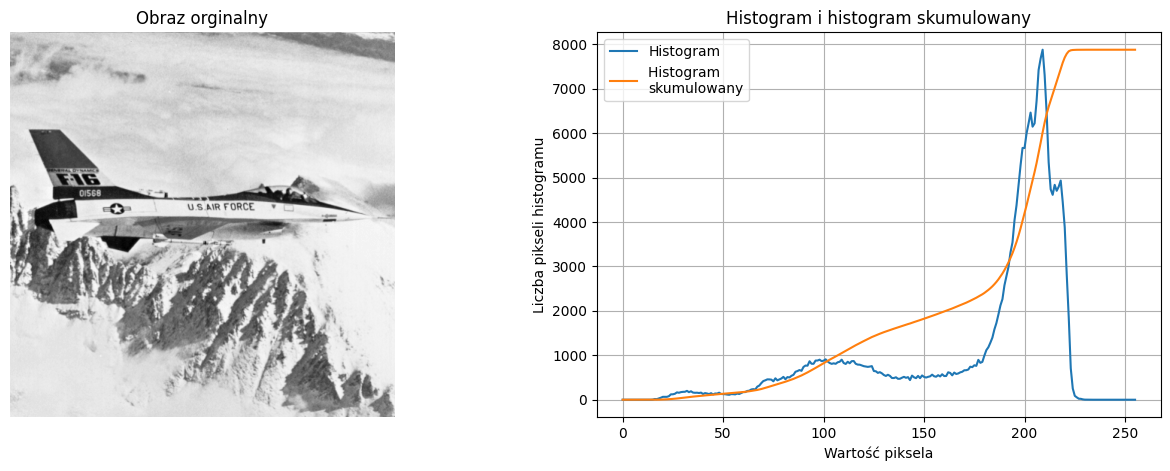

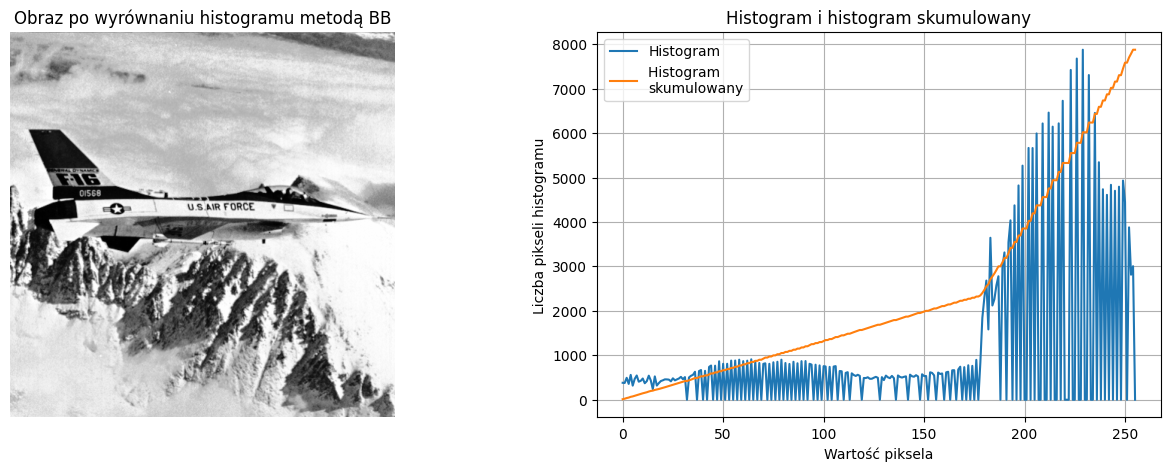

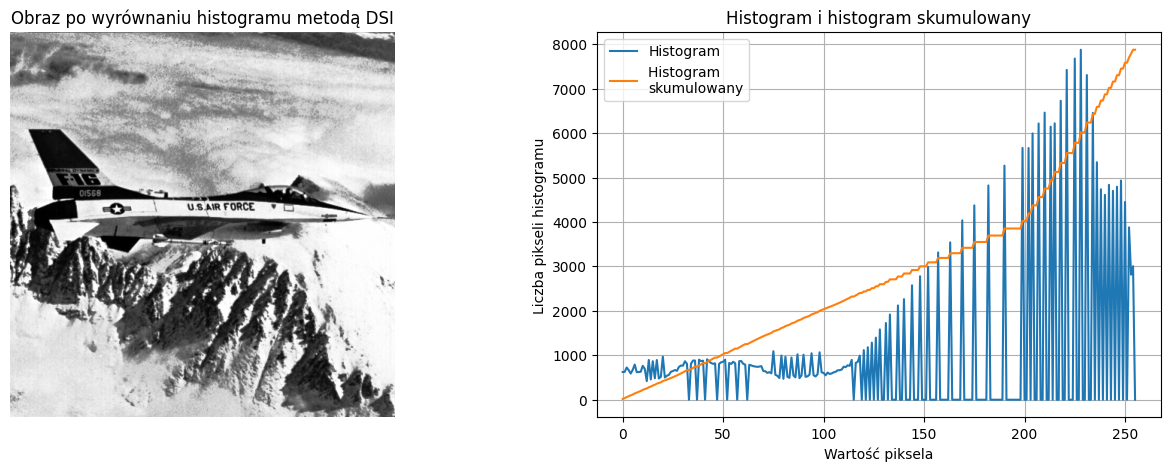

In [10]:
hist_cumulative(jet)
hist_cumulative(hist_equalize_BB(jet), "Obraz po wyrównaniu histogramu metodą BB")
hist_cumulative(hist_equalize_DSI(jet), "Obraz po wyrównaniu histogramu metodą DSI")